Team : Anna Moy & Natalie Kalukeerthie

For this project, we used the Instacart Online Grocery Shopping Dataset 2017 published on Kaggle. It was originally released by Instacart, an online grocery delivery service in the United States, to help researchers and data scientists analyze consumer purchasing patterns.

The dataset contains over 3 million grocery orders from more than 200,000 Instacart users. Each order includes detailed information on the products purchased, when they were ordered, and how often they were reordered.

This dataset is ideal for network analysis, because it naturally forms a bipartite (two-mode) network where:

- One set of nodes represents users (customers)

- The other set represents products

- Edges represent purchases (aka a user who bought a product)

 https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis?select=products.csv


We first load the Instacart data files from Kaggle. The orders file contains customer order IDs and user IDs. The order_products__prior file shows which products were in each order. The products and aisles files give product details and categories.

In [97]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

#Load the data
orders = pd.read_csv("orders.csv")
order_products = pd.read_csv("order_products__prior.csv")
products_df = pd.read_csv("products.csv")
aisles_df = pd.read_csv("aisles_instacart.csv")


Here we merge the orders and products data to connect each user with the products they’ve purchased.

In [98]:
# Merge orders with order_products to connect users and products
user_product = order_products.merge(orders[['order_id', 'user_id']], on='order_id')
user_product = user_product[['user_id', 'product_id']]
user_product.head()

,user_id,product_id
0,202279,33120
1,202279,28985
2,202279,9327
3,202279,45918
4,202279,30035


The dataset is very large (there are millions of edges). To focus on the most meaningful relationships, we use the island method to keep only strong ties:

Products purchased by ≥ 3000 users

Users who bought ≥ 200 products

Reducing the number of edges

In [99]:
# Products purchased by at least 3000 users
popular_products = (
    user_product.groupby('product_id')
    .filter(lambda x: x['user_id'].nunique() >= 3000)
)

# Users who purchased at least 200 of these popular products
active_users = (
    popular_products.groupby('user_id')
    .filter(lambda x: x['product_id'].nunique() >= 200)
)


# Final filtered dataset: only active users and popular products
filtered = active_users.copy()

print("Original edges:", len(user_product))
print("Reduced edges:", len(filtered))


Original edges: 32434489
Reduced edges: 9710


We create the bipartite graph in NetworkX with two types of nodes: users and products
And showing the number of nodes and edges it has. 

In [100]:
from networkx.algorithms import bipartite

# Make sure filtered is a copy before modifying
filtered = filtered.copy()

# Prefix node IDs for clarity
filtered['user_id'] = 'u_' + filtered['user_id'].astype(str)
filtered['product_id'] = 'p_' + filtered['product_id'].astype(str)

# Build bipartite graph
B = nx.Graph()
B.add_nodes_from(filtered['user_id'].unique(), bipartite='users')
B.add_nodes_from(filtered['product_id'].unique(), bipartite='products')

# Add edges
edges = list(zip(filtered['user_id'], filtered['product_id']))
B.add_edges_from(edges)

# Check graph
print(f"Number of nodes: {B.number_of_nodes()}")
print(f"Number of edges: {B.number_of_edges()}")
print(f"Is the graph bipartite? {bipartite.is_bipartite(B)}")

Number of nodes: 614
Number of edges: 1988
Is the graph bipartite? True


To see the connection between the users and products we plotted it in a graph. 

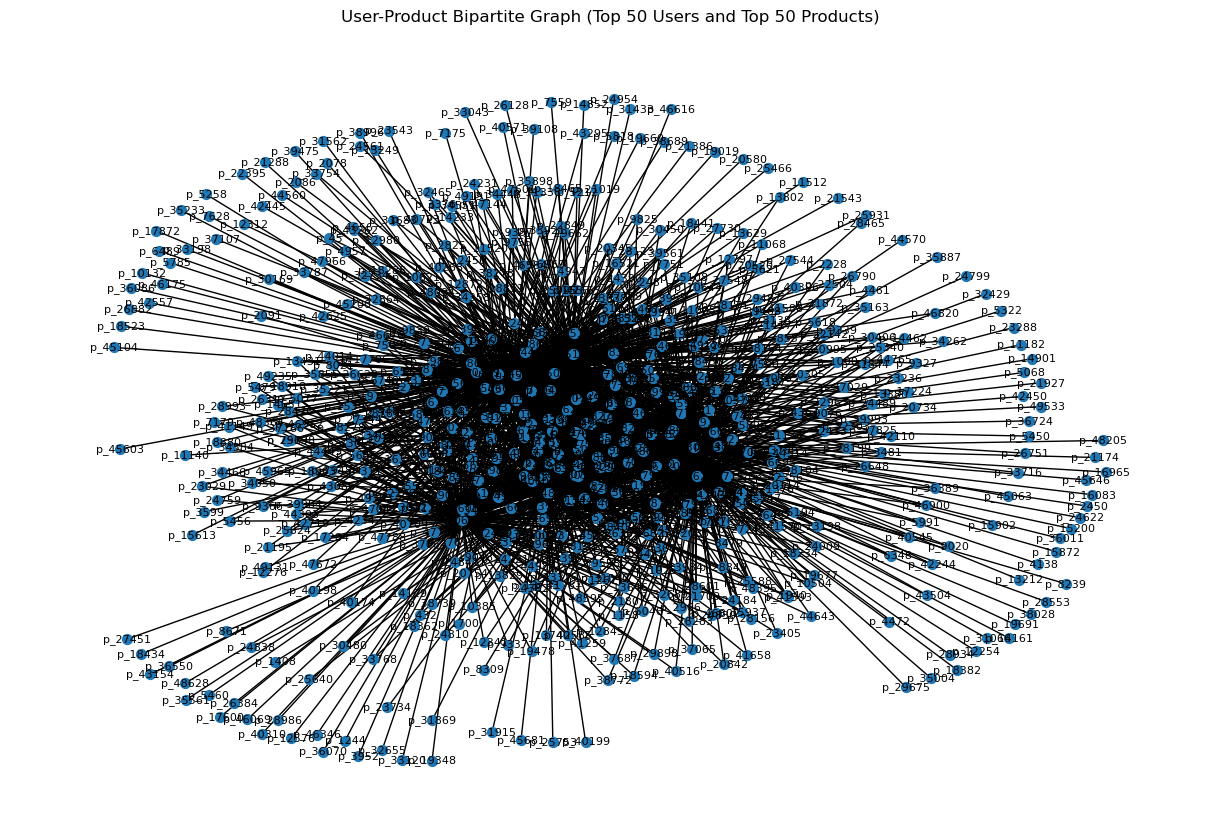

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(B, seed=42)  # positions for all nodes
nx.draw(B, pos, with_labels=True, node_size=50, font_size=8)
plt.title("User-Product Bipartite Graph (Top 50 Users and Top 50 Products)")
plt.show()

Next, we analyzed degree centrality in a bipartite network of users and products. The results show that User 182401 has connections to 42% of the products, indicating they purchase a wide variety of items. The next two connected users have 37% of the products

On the product side, all top 10 product have been purchased by 100% of the users making it the most widely bought item. 

In [102]:
# Identify user and product nodes by bipartite label
user_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'users']
product_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'products']

# Compute degree centrality for the bipartite graph
centrality = bipartite.degree_centrality(B, user_nodes)

# Separate out users and products
user_centrality = {k: v for k, v in centrality.items() if k in user_nodes}
product_centrality = {k: v for k, v in centrality.items() if k in product_nodes}

# User centrality
user_df = pd.DataFrame.from_dict(user_centrality, orient='index', columns=['degree_centrality'])
user_df.index.name = 'user_node'
user_df.reset_index(inplace=True)

# Remove 'u_' prefix for merging or labeling
user_df['user_id'] = user_df['user_node'].str.replace('u_', '', regex=False).astype(int)

# Product centrality
product_df = pd.DataFrame.from_dict(product_centrality, orient='index', columns=['degree_centrality'])
product_df.index.name = 'product_node'
product_df.reset_index(inplace=True)

# Remove 'p_' prefix and convert to int to match original product data
product_df['product_id'] = product_df['product_node'].str.replace('p_', '', regex=False).astype(int)

# Merge with product metadata (optional)
product_df = product_df.merge(products_df, on='product_id')
product_df = product_df.merge(aisles_df, on='aisle_id')

# Top 5 users by degree centrality
print("Top Active Users:")
print(user_df.sort_values('degree_centrality', ascending=False).head(5))

# Top 10 products by centrality
print("\nTop Products by Reach:")
print(product_df[['product_id', 'product_name', 'degree_centrality']].sort_values('degree_centrality', ascending=False).head(10))


Top Active Users:
  user_node  degree_centrality  user_id
7  u_182401           0.429752   182401
4  u_106161           0.376860   106161
1    u_5557           0.373554     5557
5   u_16274           0.368595    16274
3  u_148812           0.358678   148812

Top Products by Reach:
     product_id                   product_name  degree_centrality
451       34126  Organic Italian Parsley Bunch                1.0
116        4920            Seedless Red Grapes                1.0
264       21137           Organic Strawberries                1.0
4         44359     Organic Small Bunch Celery                1.0
244       39928                   Organic Kiwi                1.0
251       26209                          Limes                1.0
254       47626                    Large Lemon                1.0
66        22935           Organic Yellow Onion                1.0
122       21903           Organic Baby Spinach                1.0
33        24964                 Organic Garlic            

We grouped the product by aisle and found the average degree centrality.  It shows us what is the widely purchased items but the category. Packaged poultry was number one. 

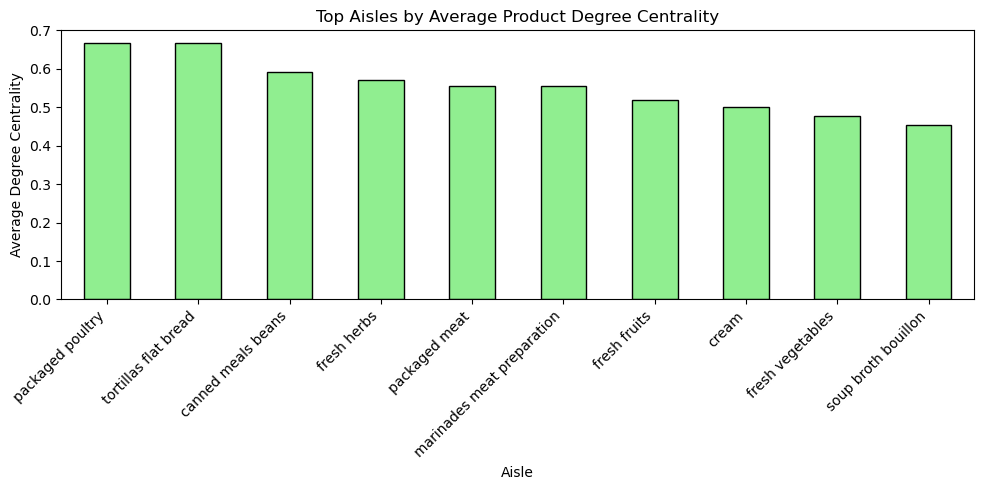

In [103]:
centrality = bipartite.degree_centrality(B, user_nodes)

#Extract product centrality only
product_centrality = {n: centrality[n] for n in product_nodes if n in centrality}


#Convert to DataFrame
product_df = pd.DataFrame.from_dict(product_centrality, orient='index', columns=['degree_centrality'])
product_df.index.name = 'product_node'
product_df.reset_index(inplace=True)

# Clean product IDs
product_df['product_id'] = product_df['product_node'].str.replace('p_', '', regex=False).astype(int)

# Merge with product metadata
product_df = product_df.merge(products_df, on='product_id', how='left')
product_df = product_df.merge(aisles_df, on='aisle_id', how='left')

# Compute average centrality per aisle
top_aisles = (
    product_df.groupby('aisle')['degree_centrality']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot results
top_aisles.plot(kind='bar', figsize=(10, 5), color='lightgreen', edgecolor='black')
plt.title("Top Aisles by Average Product Degree Centrality")
plt.ylabel("Average Degree Centrality")
plt.xlabel("Aisle")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



We conducted a Jaccard similarity score between the users and it shows user 130393 and 148812 had 35% overlap in the products they bought. These two users have a similar shopping preference. 

Jaccard Similarity - measure the similiar between two sets. 

In [104]:
from itertools import combinations

# Get user nodes
user_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'users']

# For each user, get the set of products they bought
user_products = {user: set(B.neighbors(user)) for user in user_nodes}

# Calculate Jaccard similarity for all user pairs
jaccard_sim = {}
for u1, u2 in combinations(user_nodes, 2):
    products_u1 = user_products[u1]
    products_u2 = user_products[u2]
    intersection = products_u1.intersection(products_u2)
    union = products_u1.union(products_u2)
    if union:
        jaccard_sim[(u1, u2)] = len(intersection) / len(union)
    else:
        jaccard_sim[(u1, u2)] = 0

# Convert to DataFrame for easier analysis
import pandas as pd
jaccard_df = pd.DataFrame(
    [(k[0], k[1], v) for k, v in jaccard_sim.items()],
    columns=['user1', 'user2', 'jaccard_similarity']
)

# Show top 10 most similar user pairs
print(jaccard_df.sort_values(by='jaccard_similarity', ascending=False).head(10))


       user1     user2  jaccard_similarity
13  u_130393  u_148812            0.359873
12  u_130393   u_16274            0.353125
33   u_16274  u_148812            0.337386
9   u_130393  u_150100            0.334416
30   u_81140   u_16274            0.331269
23  u_150100   u_16274            0.329154
22  u_150100   u_81140            0.324675
0   u_151378  u_130393            0.322981
16  u_106161  u_182401            0.322493
17  u_106161   u_81140            0.322188
